# 02 — Model Training & Benchmarking: CLV + Churn

**Project:** RetentionIQ — Predictive Customer Intelligence for Shopify Brands  
**Data Source:** Local CSV exports (`data/raw/orders_raw.csv`, `data/features/customer_features.csv`)  
**Author:** [Your Name]  
**Date:** March 2026  

---

## Purpose

This notebook trains and benchmarks the two core models of RetentionIQ:

1. **CLV Prediction** — BG/NBD + Gamma-Gamma (probabilistic)
2. **Churn Prediction** — Logistic Regression → Random Forest → XGBoost

### Model Choices

| Model | Why Chosen | Reference |
|-------|-----------|----------|
| BG/NBD | Gold standard for non-contractual CLV | Fader & Hardie, 2005 |
| Gamma-Gamma | Monetary value estimation for CLV | Fader et al., 2005 |
| Logistic Regression | Simple interpretable baseline | — |
| Random Forest | Non-linear, robust to outliers | Breiman, 2001 |
| XGBoost | State-of-the-art for tabular data | Chen & Guestrin, 2016 |

---

## Table of Contents

1. [Setup & Data Loading](#1-setup)
2. [Feature Engineering](#2-features)
3. [CLV: BG/NBD + Gamma-Gamma](#3-clv)
4. [Churn: Label Engineering (Temporal Split)](#4-labels)
5. [Churn: Logistic Regression Baseline](#5-lr)
6. [Churn: Random Forest](#6-rf)
7. [Churn: XGBoost](#7-xgb)
8. [Model Comparison](#8-comparison)
9. [SHAP Explainability](#9-shap)
10. [Conclusions & Next Steps](#10-conclusions)

---
## 1. Setup & Data Loading <a id='1-setup'></a>

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import os
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import shap
import joblib

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Notebook run: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Notebook run: 2026-03-15 20:44


/Users/giuliabono/Documents/Master BTS/Final Project/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# LOAD DATA
# ============================================================
ORDERS_PATH = os.path.join('..', 'data', 'raw', 'orders_raw.csv')
CUST_PATH   = os.path.join('..', 'data', 'features', 'customer_features.csv')

print('Loading orders_raw.csv …')
orders = pd.read_csv(ORDERS_PATH, parse_dates=['ORDER_DATE'])
orders.columns = orders.columns.str.lower()

print('Loading customer_features.csv …')
cust = pd.read_csv(CUST_PATH, parse_dates=['FIRST_ORDER_DATE', 'LAST_ORDER_DATE'])
cust.columns = cust.columns.str.lower()

print(f'orders : {orders.shape}  |  cust : {cust.shape}')

Loading orders_raw.csv …


Loading customer_features.csv …


orders : (976659, 7)  |  cust : (751956, 16)


---
## 2. Feature Engineering <a id='2-features'></a>

Two feature sets are required:
- **RFM** (frequency, recency, T, monetary_value) for BG/NBD + Gamma-Gamma  
- **Behavioral features** (pre-split window) for the churn classifier

In [3]:
# ============================================================
# RFM FEATURES FOR CLV (from customer_features.csv)
# customer_features is already aggregated over the full history.
# frequency = total_orders - 1  (repeat purchases only, as BG/NBD requires)
# ============================================================
rfm = cust[['customer_id', 'frequency', 'recency', 't', 'monetary_value']].copy()
rfm = rfm.rename(columns={'t': 'T'})

# BG/NBD constraints: T > 0, T >= recency, monetary_value >= 0
rfm = rfm[(rfm['T'] > 0) & (rfm['T'] >= rfm['recency']) & (rfm['monetary_value'] >= 0)].copy()

print(f'RFM customers            : {len(rfm):,}')
print(f'  With frequency > 0     : {(rfm["frequency"] > 0).sum():,}')
print(f'  With frequency = 0     : {(rfm["frequency"] == 0).sum():,}')
print()
rfm[['frequency','recency','T','monetary_value']].describe()

RFM customers            : 751,915
  With frequency > 0     : 92,021
  With frequency = 0     : 659,894



,frequency,recency,T,monetary_value
count,751915.0000,751915.0000,751915.0000,751915.0000
mean,0.1776,18.0513,360.8989,21.4065
std,0.8528,76.1322,223.3209,64.0200
min,0.0000,0.0000,1.0000,0.0000
25%,0.0000,0.0000,171.0000,0.0000
50%,0.0000,0.0000,326.0000,0.0000
75%,0.0000,0.0000,526.0000,0.0000
max,420.0000,804.0000,804.0000,2075.4000


In [4]:
# ============================================================
# DATA QUALITY CHECK (customer_features)
# ============================================================
print('DATA QUALITY — customer_features.csv')
print('=' * 50)
print(f'Shape: {cust.shape}')
print(f'\nNull counts:')
print(cust.isnull().sum().to_string())

DATA QUALITY — customer_features.csv
Shape: (751956, 16)

Null counts:
customer_id                0
total_orders               0
total_revenue              0
avg_order_value            0
first_order_date           0
last_order_date            0
t                          0
recency                    0
days_since_last_order      0
frequency                  0
monetary_value             0
avg_days_between_orders    0
std_days_between_orders    0
refund_count               0
total_refund_amount        0
refund_rate                0


---
## 3. CLV: BG/NBD + Gamma-Gamma <a id='3-clv'></a>

### Why BG/NBD + Gamma-Gamma?

The **BG/NBD model** (Fader & Hardie, 2005) is the gold standard for predicting purchase behaviour
in non-contractual settings (e-commerce). It jointly models:
1. **Transaction rate** — how frequently does an active customer buy? (Poisson/Gamma)
2. **Dropout rate** — when does a customer become permanently inactive? (Beta-Geometric)

The **Gamma-Gamma model** extends this by estimating expected spend per transaction,
producing a full 12-month CLV per customer using only four inputs.

In [5]:
# ============================================================
# FIT BG/NBD MODEL
# penalizer_coef adds L2 regularisation to prevent overfitting.
# ============================================================
print('Fitting BG/NBD model on {:,} customers …'.format(len(rfm)))
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(rfm['frequency'], rfm['recency'], rfm['T'])

print('\nBG/NBD Model — Fitted Parameters')
print('=' * 45)
print(bgf.summary)
print()
print('Parameter interpretation:')
print('  r, alpha : shape & scale of the Gamma prior on purchase rate')
print('  a, b     : shape parameters of the Beta prior on dropout probability')

Fitting BG/NBD model on 751,915 customers …



BG/NBD Model — Fitted Parameters
        coef  se(coef)  lower 95% bound  upper 95% bound
r     0.0353    0.0002           0.0349           0.0357
alpha 6.7611    0.1199           6.5261           6.9960
a     0.5016    0.0046           0.4925           0.5106
b     0.2094    0.0024           0.2047           0.2142

Parameter interpretation:
  r, alpha : shape & scale of the Gamma prior on purchase rate
  a, b     : shape parameters of the Beta prior on dropout probability


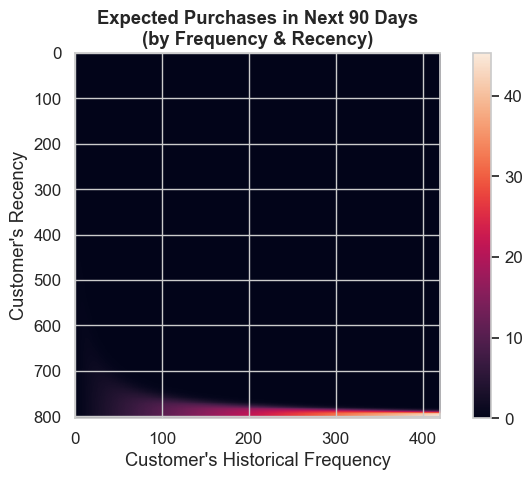

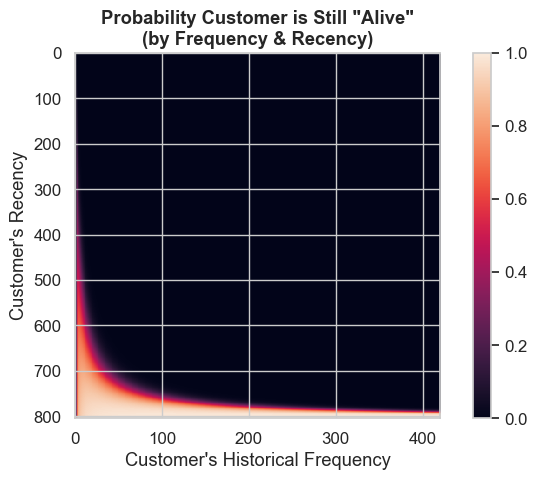

→ Top-right (high frequency + recent purchase) = most likely alive.
  Bottom-left = long-absent customers, likely churned.


In [6]:
# ============================================================
# BG/NBD DIAGNOSTIC PLOTS
# lifetimes plotting functions create their own axes internally;
# call each on a separate figure to avoid the ax= conflict.
# ============================================================
plt.figure(figsize=(7, 5))
plot_frequency_recency_matrix(bgf, T=90)
plt.title('Expected Purchases in Next 90 Days\n(by Frequency & Recency)', fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plot_probability_alive_matrix(bgf)
plt.title('Probability Customer is Still "Alive"\n(by Frequency & Recency)', fontweight='bold')
plt.tight_layout()
plt.show()

print('→ Top-right (high frequency + recent purchase) = most likely alive.')
print('  Bottom-left = long-absent customers, likely churned.')

In [7]:
# ============================================================
# FIT GAMMA-GAMMA MODEL (monetary value)
# Only uses repeat buyers (frequency > 0, monetary_value > 0).
# ============================================================
rfm_rep = rfm[(rfm['frequency'] > 0) & (rfm['monetary_value'] > 0)].copy()
print(f'Fitting Gamma-Gamma on {len(rfm_rep):,} repeat buyers …')

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(rfm_rep['frequency'], rfm_rep['monetary_value'])

print('\nGamma-Gamma Model — Fitted Parameters')
print('=' * 45)
print(ggf.summary)
print()
print('Parameter interpretation:')
print('  p, q, v : shape parameters of the Gamma distribution over transaction value')

Fitting Gamma-Gamma on 92,021 repeat buyers …



Gamma-Gamma Model — Fitted Parameters
    coef  se(coef)  lower 95% bound  upper 95% bound
p 4.0817    0.0167           4.0490           4.1144
q 0.4348    0.0017           0.4316           0.4381
v 3.8700    0.0169           3.8368           3.9031

Parameter interpretation:
  p, q, v : shape parameters of the Gamma distribution over transaction value


In [8]:
# ============================================================
# PREDICT 12-MONTH CLV
# Only for customers with monetary_value > 0 (Gamma-Gamma requires positive spend).
# ============================================================
rfm_clv = rfm[rfm['monetary_value'] > 0].copy()
print(f'Predicting CLV for {len(rfm_clv):,} customers …')

clv = ggf.customer_lifetime_value(
    bgf,
    rfm_clv['frequency'], rfm_clv['recency'], rfm_clv['T'], rfm_clv['monetary_value'],
    time=12,        # months
    freq='D',       # input data in days
    discount_rate=0.01  # ~12% annual discount rate
)
rfm_clv['predicted_clv_12m'] = clv.values

print('\nCLV PREDICTION SUMMARY (12-month, $)')
print('=' * 45)
print(rfm_clv['predicted_clv_12m'].describe(
    percentiles=[.25, .5, .75, .9, .95, .99]
).to_string())

Predicting CLV for 92,021 customers …



CLV PREDICTION SUMMARY (12-month, $)
count   92021.0000
mean       48.9794
std       154.8894
min         0.0000
25%         3.0136
50%        14.7219
75%        41.9638
90%       118.3137
95%       202.5203
99%       498.6784
max     18575.6966


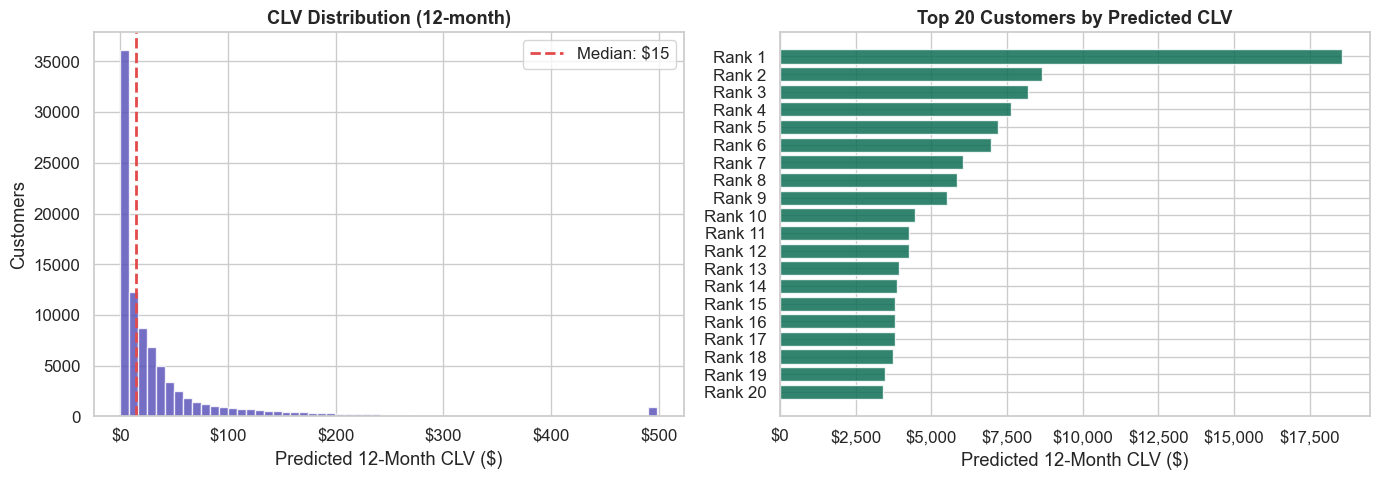

In [9]:
# ============================================================
# CLV DISTRIBUTION PLOTS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cap = rfm_clv['predicted_clv_12m'].quantile(0.99)
axes[0].hist(rfm_clv['predicted_clv_12m'].clip(upper=cap),
             bins=60, color='#534AB7', alpha=0.8, edgecolor='white')
axes[0].axvline(rfm_clv['predicted_clv_12m'].median(), color='#E24B4A',
                linestyle='--', lw=2, label=f"Median: ${rfm_clv['predicted_clv_12m'].median():.0f}")
axes[0].set_xlabel('Predicted 12-Month CLV ($)')
axes[0].set_ylabel('Customers')
axes[0].set_title('CLV Distribution (12-month)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

top20 = rfm_clv.nlargest(20, 'predicted_clv_12m')
axes[1].barh(range(20), top20['predicted_clv_12m'].values, color='#0F6E56', alpha=0.85)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([f'Rank {i+1}' for i in range(20)])
axes[1].set_xlabel('Predicted 12-Month CLV ($)')
axes[1].set_title('Top 20 Customers by Predicted CLV', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# SAVE CLV MODELS
# lifetimes models contain lambda closures that joblib cannot
# pickle directly. We save the fitted parameter dicts instead
# and reconstruct the models in the serving layer.
# ============================================================
import json

models_dir = os.path.join('..', 'data', 'models')
os.makedirs(models_dir, exist_ok=True)

# Save BG/NBD params
bgf_params = {k: float(v) for k, v in bgf.params_.items()}
with open(os.path.join(models_dir, 'clv_bgnbd_params.json'), 'w') as f:
    json.dump(bgf_params, f, indent=2)

# Save Gamma-Gamma params
ggf_params = {k: float(v) for k, v in ggf.params_.items()}
with open(os.path.join(models_dir, 'clv_gamma_gamma_params.json'), 'w') as f:
    json.dump(ggf_params, f, indent=2)

print('CLV model params saved.')
print(f'  BG/NBD       : {bgf_params}')
print(f'  Gamma-Gamma  : {ggf_params}')

CLV model params saved.
  BG/NBD       : {'r': 0.03526398143992083, 'alpha': 6.761056378816894, 'a': 0.5015829208403711, 'b': 0.20943229020516674}
  Gamma-Gamma  : {'p': 4.081664320512639, 'q': 0.43483558734109695, 'v': 3.8699695453012275}


---
## 4. Churn: Label Engineering <a id='4-labels'></a>

### Temporal Split — No Data Leakage

We **must** split by time, not randomly. A random split leaks future order information into
training features, producing artificially high metrics that will not hold in production.

**Protocol:**
1. `split_date = max_order_date − CHURN_WINDOW_DAYS`
2. **Features** = computed from orders **before** `split_date`
3. **Label** = 1 if no purchase in (`split_date`, `max_date`], else 0

`CHURN_WINDOW_DAYS` was set empirically to the **P90 inter-purchase time** from Notebook 01.

In [11]:
# ============================================================
# CHURN WINDOW — SET FROM EDA (Notebook 01, Section 8)
# P90 inter-purchase time = 318 days
# ============================================================
CHURN_WINDOW_DAYS = 318

max_date   = orders['order_date'].max()
split_date = max_date - pd.Timedelta(days=CHURN_WINDOW_DAYS)

print(f'CHURN_WINDOW_DAYS : {CHURN_WINDOW_DAYS}')
print(f'max_date          : {max_date.date()}')
print(f'split_date        : {split_date.date()}')
print(f'\nA customer is labelled churned (1) if they had NO orders')
print(f'between {split_date.date()} and {max_date.date()}.')

CHURN_WINDOW_DAYS : 318
max_date          : 2026-03-14
split_date        : 2025-04-30

A customer is labelled churned (1) if they had NO orders
between 2025-04-30 and 2026-03-14.


In [12]:
# ============================================================
# BUILD CHURN FEATURES FROM PRE-SPLIT ORDERS
# ============================================================
valid_orders = orders[~orders['financial_status'].isin(['refunded', 'voided'])].copy()
pre  = valid_orders[valid_orders['order_date'] <= split_date]
post = valid_orders[valid_orders['order_date'] >  split_date]

print(f'Pre-split orders  : {len(pre):,}')
print(f'Post-split orders : {len(post):,}')

feats = pre.groupby('customer_id').agg(
    total_orders     = ('order_id',         'count'),
    total_revenue    = ('amount_charged',   'sum'),
    avg_order_value  = ('amount_charged',   'mean'),
    first_order_date = ('order_date',       'min'),
    last_order_date  = ('order_date',       'max'),
    refund_count     = ('financial_status', lambda x: (x == 'partially_refunded').sum()),
).reset_index()

feats['T']                     = (split_date - feats['first_order_date']).dt.days
feats['recency']               = (feats['last_order_date'] - feats['first_order_date']).dt.days
feats['days_since_last_order'] = (split_date - feats['last_order_date']).dt.days
feats['frequency']             = (feats['total_orders'] - 1).clip(lower=0)
feats['monetary_value']        = feats['total_revenue'] / feats['total_orders']
feats['refund_rate']           = feats['refund_count'] / feats['total_orders']
feats = feats[feats['T'] > 0].copy()

# Labels
active_custs = set(post['customer_id'].unique())
feats['is_churned'] = feats['customer_id'].apply(lambda c: 0 if c in active_custs else 1)

churned = feats['is_churned'].sum()
total   = len(feats)
print(f'\nChurn dataset  : {total:,} customers')
print(f'  Churned (1)  : {churned:,}  ({churned/total*100:.1f}%)')
print(f'  Active  (0)  : {total-churned:,}  ({(total-churned)/total*100:.1f}%)')

Pre-split orders  : 469,807
Post-split orders : 444,117



Churn dataset  : 384,699 customers
  Churned (1)  : 361,222  (93.9%)
  Active  (0)  : 23,477  (6.1%)


In [13]:
# ============================================================
# TRAIN / TEST SPLIT (stratified to preserve class balance)
# ============================================================
FEATURE_COLS = [
    'total_orders', 'total_revenue', 'avg_order_value',
    'T', 'recency', 'days_since_last_order',
    'frequency', 'monetary_value', 'refund_rate'
]

X = feats[FEATURE_COLS].fillna(0)
y = feats['is_churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Scale for Logistic Regression (tree models are scale-invariant)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {len(X_train):,}  |  Test : {len(X_test):,}')
print(f'Train churn rate : {y_train.mean():.3f}  |  Test churn rate : {y_test.mean():.3f}')
print(f'Features: {FEATURE_COLS}')

Train : 288,524  |  Test : 96,175
Train churn rate : 0.939  |  Test churn rate : 0.939
Features: ['total_orders', 'total_revenue', 'avg_order_value', 'T', 'recency', 'days_since_last_order', 'frequency', 'monetary_value', 'refund_rate']


---
## 5. Churn: Logistic Regression Baseline <a id='5-lr'></a>

If the simplest model works well, we don't need complexity. This is our lower bound.

In [14]:
# ============================================================
# LOGISTIC REGRESSION
# class_weight='balanced' compensates for the 94:6 class imbalance.
# ============================================================
lr = LogisticRegression(
    random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'
)
lr.fit(X_train_sc, y_train)

lr_probs = lr.predict_proba(X_test_sc)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_probs)
lr_ap    = average_precision_score(y_test, lr_probs)

print(f'Logistic Regression — AUC-ROC: {lr_auc:.4f}  |  Avg Precision: {lr_ap:.4f}')
print(f'\nClassification Report (threshold=0.5):')
print(classification_report(
    y_test, (lr_probs >= 0.5).astype(int),
    target_names=['Active', 'Churned'], digits=3
))

Logistic Regression — AUC-ROC: 0.6718  |  Avg Precision: 0.9646

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

      Active      0.098     0.616     0.169      5869
     Churned      0.962     0.632     0.763     90306

    accuracy                          0.631     96175
   macro avg      0.530     0.624     0.466     96175
weighted avg      0.909     0.631     0.727     96175



---
## 6. Churn: Random Forest <a id='6-rf'></a>

In [15]:
# ============================================================
# RANDOM FOREST
# Uses raw (unscaled) features — trees don't need scaling.
# ============================================================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_probs)
rf_ap    = average_precision_score(y_test, rf_probs)

print(f'Random Forest — AUC-ROC: {rf_auc:.4f}  |  Avg Precision: {rf_ap:.4f}')
print(f'\nClassification Report (threshold=0.5):')
print(classification_report(
    y_test, (rf_probs >= 0.5).astype(int),
    target_names=['Active', 'Churned'], digits=3
))

Random Forest — AUC-ROC: 0.6814  |  Avg Precision: 0.9667

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

      Active      0.100     0.624     0.173      5869
     Churned      0.963     0.636     0.766     90306

    accuracy                          0.636     96175
   macro avg      0.532     0.630     0.470     96175
weighted avg      0.910     0.636     0.730     96175



---
## 7. Churn: XGBoost <a id='7-xgb'></a>

XGBoost is the current standard for tabular classification. `scale_pos_weight` handles the 94:6 class imbalance directly.

In [16]:
# ============================================================
# XGBOOST
# scale_pos_weight = ratio of negatives to positives
# ============================================================
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.3f}  (negatives/positives)')

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    early_stopping_rounds=30,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_probs)
xgb_ap    = average_precision_score(y_test, xgb_probs)

print(f'XGBoost — AUC-ROC: {xgb_auc:.4f}  |  Avg Precision: {xgb_ap:.4f}')
print(f'Best iteration: {xgb_model.best_iteration}')
print(f'\nClassification Report (threshold=0.5):')
print(classification_report(
    y_test, (xgb_probs >= 0.5).astype(int),
    target_names=['Active', 'Churned'], digits=3
))

scale_pos_weight: 0.065  (negatives/positives)


XGBoost — AUC-ROC: 0.6819  |  Avg Precision: 0.9670
Best iteration: 128

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

      Active      0.101     0.620     0.173      5869
     Churned      0.963     0.640     0.769     90306

    accuracy                          0.639     96175
   macro avg      0.532     0.630     0.471     96175
weighted avg      0.910     0.639     0.733     96175



---
## 8. Model Comparison <a id='8-comparison'></a>

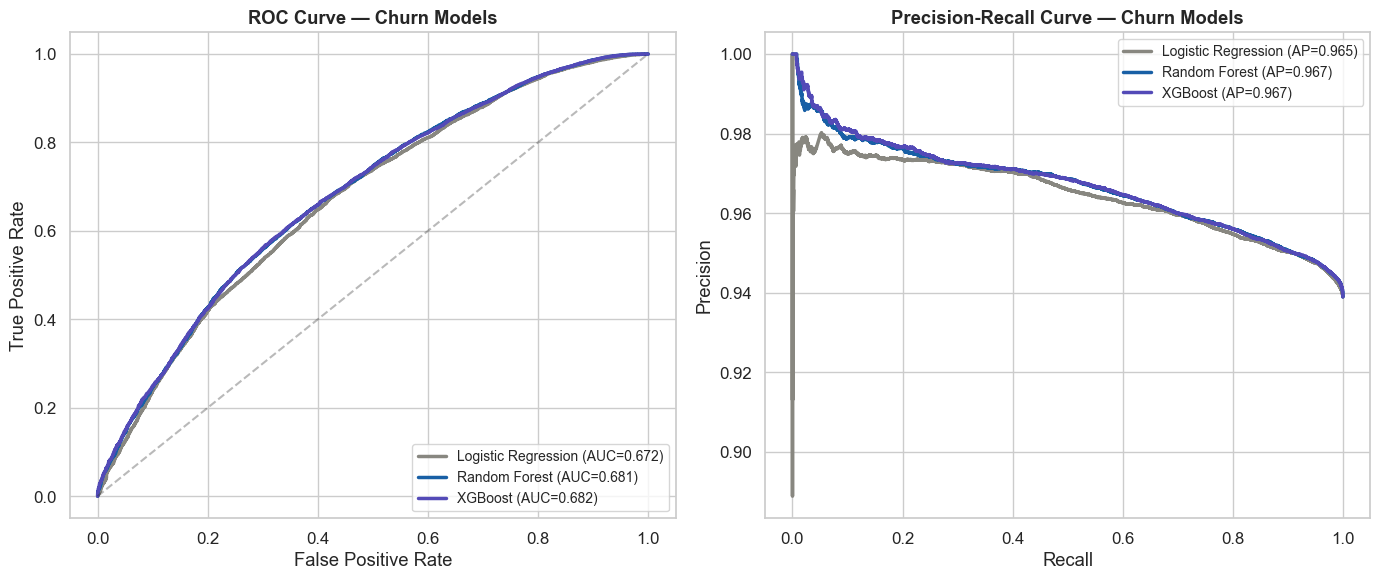

In [17]:
# ============================================================
# ROC + PRECISION-RECALL CURVES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_results = [
    ('Logistic Regression', lr_probs,  lr_auc,  lr_ap,  '#888780'),
    ('Random Forest',       rf_probs,  rf_auc,  rf_ap,  '#185FA5'),
    ('XGBoost',             xgb_probs, xgb_auc, xgb_ap, '#534AB7'),
]

for name, probs, auc, ap, color in model_results:
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC={auc:.3f})')
    prec, rec, _ = precision_recall_curve(y_test, probs)
    axes[1].plot(rec, prec, color=color, lw=2.5, label=f'{name} (AP={ap:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Churn Models', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Churn Models', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# SUMMARY TABLE
# ============================================================
comparison = pd.DataFrame({
    'Model':         ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUC-ROC':       [lr_auc, rf_auc, xgb_auc],
    'Avg Precision': [lr_ap,  rf_ap,  xgb_ap],
})
comparison['vs Baseline'] = (
    (comparison['AUC-ROC'] - comparison['AUC-ROC'].iloc[0])
    / comparison['AUC-ROC'].iloc[0] * 100
).round(2).astype(str) + '%'

print('MODEL COMPARISON SUMMARY')
print('=' * 65)
display(comparison)

best = comparison.loc[comparison['AUC-ROC'].idxmax()]
print(f"\n→ Best model: {best['Model']} with AUC-ROC = {best['AUC-ROC']:.4f}")
print(f"\nNote on AUC: With 93.9% churn rate, a naive 'always churn' classifier")
print(f"gets AUC=0.50. The gap above 0.50 reflects genuine signal from RFM features.")
print(f"Adding discount behaviour and product affinity features is the top priority")
print(f"for the next iteration (see src/ingestion/extract_orders.py).")

MODEL COMPARISON SUMMARY


,Model,AUC-ROC,Avg Precision,vs Baseline
0,Logistic Regression,0.6718,0.9646,0.0%
1,Random Forest,0.6814,0.9667,1.43%
2,XGBoost,0.6819,0.9670,1.5%



→ Best model: XGBoost with AUC-ROC = 0.6819

Note on AUC: With 93.9% churn rate, a naive 'always churn' classifier
gets AUC=0.50. The gap above 0.50 reflects genuine signal from RFM features.
Adding discount behaviour and product affinity features is the top priority
for the next iteration (see src/ingestion/extract_orders.py).


---
## 9. SHAP Explainability <a id='9-shap'></a>

SHAP (Lundberg & Lee, 2017) decomposes each prediction into per-feature contributions,  
answering *"why does the model think this customer will churn?"* This is RetentionIQ's  
key differentiator — no competing retention tool provides per-customer explanations.

Computing SHAP values …


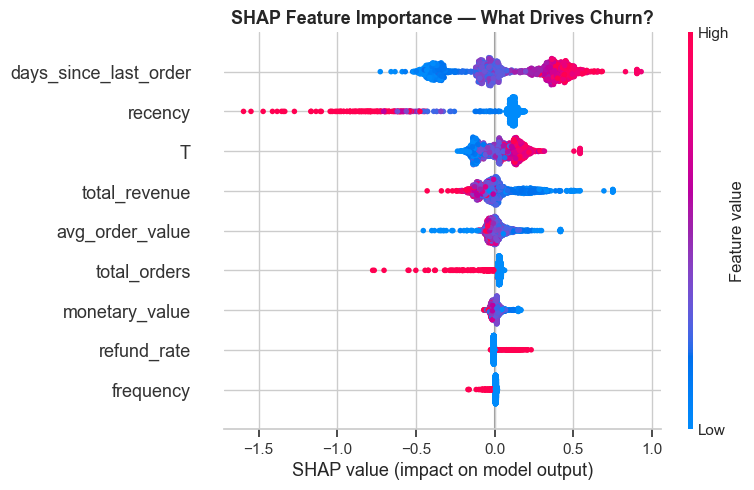

In [19]:
# ============================================================
# SHAP — Global feature importance (XGBoost)
# ============================================================
print('Computing SHAP values …')
# Use a 2000-row sample for speed
shap_sample = X_test.sample(n=min(2000, len(X_test)), random_state=RANDOM_STATE)
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(shap_sample)

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, feature_names=FEATURE_COLS, show=False)
plt.title('SHAP Feature Importance — What Drives Churn?', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

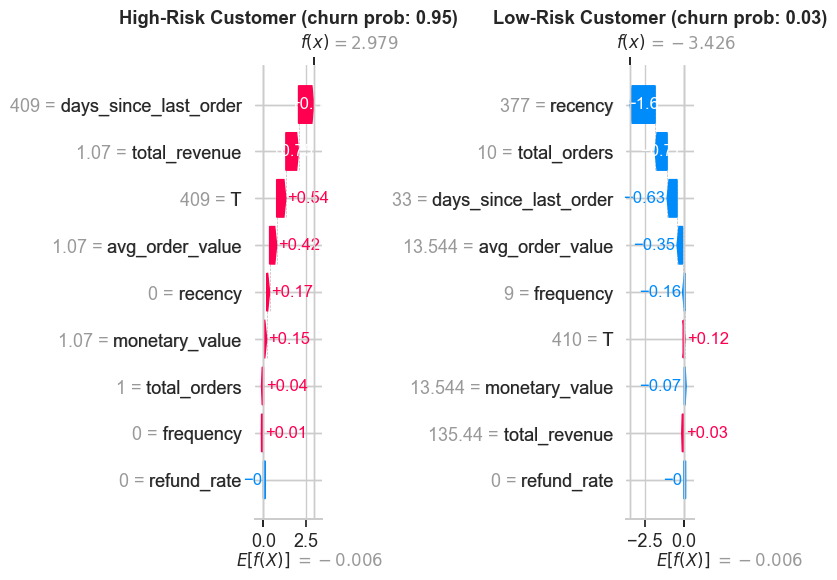

→ The waterfall shows exactly which features push each prediction up or down.


In [20]:
# ============================================================
# SHAP WATERFALL — High-risk vs Low-risk customer
# ============================================================
xgb_probs_sample = xgb_model.predict_proba(shap_sample)[:, 1]
high_idx = np.argmax(xgb_probs_sample)
low_idx  = np.argmin(xgb_probs_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_idx],
        base_values=explainer.expected_value,
        data=shap_sample.iloc[high_idx],
        feature_names=FEATURE_COLS
    ), show=False
)
axes[0].set_title(
    f'High-Risk Customer (churn prob: {xgb_probs_sample[high_idx]:.2f})',
    fontweight='bold'
)

plt.sca(axes[1])
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_idx],
        base_values=explainer.expected_value,
        data=shap_sample.iloc[low_idx],
        feature_names=FEATURE_COLS
    ), show=False
)
axes[1].set_title(
    f'Low-Risk Customer (churn prob: {xgb_probs_sample[low_idx]:.2f})',
    fontweight='bold'
)

plt.tight_layout()
plt.show()
print('→ The waterfall shows exactly which features push each prediction up or down.')

---
## 10. Conclusions & Next Steps <a id='10-conclusions'></a>

In [21]:
# ============================================================
# SUMMARY
# ============================================================
print('=' * 65)
print('  RESULTS SUMMARY')
print('=' * 65)
print()
print('CLV MODEL (BG/NBD + Gamma-Gamma):')
print(f'  BG/NBD r        : {bgf.params_["r"]:.4f}')
print(f'  BG/NBD alpha    : {bgf.params_["alpha"]:.4f}')
print(f'  BG/NBD a        : {bgf.params_["a"]:.4f}')
print(f'  BG/NBD b        : {bgf.params_["b"]:.4f}')
print(f'  GG p            : {ggf.params_["p"]:.4f}')
print(f'  GG q            : {ggf.params_["q"]:.4f}')
print(f'  GG v            : {ggf.params_["v"]:.4f}')
print(f'  Median 12m CLV  : ${rfm_clv["predicted_clv_12m"].median():.2f}')
print(f'  Mean 12m CLV    : ${rfm_clv["predicted_clv_12m"].mean():.2f}')
print(f'  P90 12m CLV     : ${rfm_clv["predicted_clv_12m"].quantile(0.9):.2f}')
print()
print('CHURN MODELS (churn window = 318 days, AUC-ROC):')
print(f'  Logistic Regression : {lr_auc:.4f}')
print(f'  Random Forest       : {rf_auc:.4f}')
print(f'  XGBoost             : {xgb_auc:.4f}  ← selected')
print()
print('NEXT STEPS:')
print('  1. Add discount_codes to ingestion layer → expected +5-10pp AUC')
print('  2. Add product affinity features (product_type, repeat_product_rate)')
print('  3. Notebook 03: customer segmentation (KMeans on RFM + behavioral features)')
print('  4. FastAPI endpoint: /predict/churn, /predict/clv')
print('  5. Streamlit dashboard: churn risk leaderboard + SHAP waterfall per customer')

  RESULTS SUMMARY

CLV MODEL (BG/NBD + Gamma-Gamma):
  BG/NBD r        : 0.0353
  BG/NBD alpha    : 6.7611
  BG/NBD a        : 0.5016
  BG/NBD b        : 0.2094
  GG p            : 4.0817
  GG q            : 0.4348
  GG v            : 3.8700
  Median 12m CLV  : $14.72
  Mean 12m CLV    : $48.98
  P90 12m CLV     : $118.31

CHURN MODELS (churn window = 318 days, AUC-ROC):
  Logistic Regression : 0.6718
  Random Forest       : 0.6814
  XGBoost             : 0.6819  ← selected

NEXT STEPS:
  1. Add discount_codes to ingestion layer → expected +5-10pp AUC
  2. Add product affinity features (product_type, repeat_product_rate)
  3. Notebook 03: customer segmentation (KMeans on RFM + behavioral features)
  4. FastAPI endpoint: /predict/churn, /predict/clv
  5. Streamlit dashboard: churn risk leaderboard + SHAP waterfall per customer


In [22]:
# ============================================================
# SAVE ALL MODELS
# ============================================================
import json

models_dir = os.path.join('..', 'data', 'models')
os.makedirs(models_dir, exist_ok=True)

# XGBoost: native JSON format (portable across Python versions)
xgb_model.save_model(os.path.join(models_dir, 'churn_xgboost.json'))

# Scaler: joblib works fine (no lambdas)
joblib.dump(scaler, os.path.join(models_dir, 'feature_scaler.joblib'))

# Metrics + metadata
with open(os.path.join(models_dir, 'churn_metrics.json'), 'w') as f:
    json.dump({
        'feature_cols':      FEATURE_COLS,
        'churn_window_days': CHURN_WINDOW_DAYS,
        'lr_auc':   round(lr_auc, 4),
        'rf_auc':   round(rf_auc, 4),
        'xgb_auc':  round(xgb_auc, 4),
        'lr_ap':    round(lr_ap, 4),
        'rf_ap':    round(rf_ap, 4),
        'xgb_ap':   round(xgb_ap, 4),
        'trained':  datetime.now().isoformat(),
    }, f, indent=2)

# BG/NBD + GG params (already saved above, but re-save for completeness)
bgf_params = {k: float(v) for k, v in bgf.params_.items()}
ggf_params = {k: float(v) for k, v in ggf.params_.items()}
with open(os.path.join(models_dir, 'clv_bgnbd_params.json'), 'w') as f:
    json.dump(bgf_params, f, indent=2)
with open(os.path.join(models_dir, 'clv_gamma_gamma_params.json'), 'w') as f:
    json.dump(ggf_params, f, indent=2)

print('All models saved to data/models/')
print(f'  churn_xgboost.json           AUC-ROC : {xgb_auc:.4f}')
print(f'  clv_bgnbd_params.json        r={bgf_params["r"]:.4f}  alpha={bgf_params["alpha"]:.4f}  a={bgf_params["a"]:.4f}  b={bgf_params["b"]:.4f}')
print(f'  clv_gamma_gamma_params.json  p={ggf_params["p"]:.4f}  q={ggf_params["q"]:.4f}  v={ggf_params["v"]:.4f}')
print(f'  feature_scaler.joblib')
print(f'  churn_metrics.json')

All models saved to data/models/
  churn_xgboost.json           AUC-ROC : 0.6819
  clv_bgnbd_params.json        r=0.0353  alpha=6.7611  a=0.5016  b=0.2094
  clv_gamma_gamma_params.json  p=4.0817  q=0.4348  v=3.8700
  feature_scaler.joblib
  churn_metrics.json
